In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [2]:
torch.__version__

'2.4.0'

## 1.Pytorch tensor

In [3]:
a = torch.tensor([1, 2, 3])
a

tensor([1, 2, 3])

In [4]:
b = torch.tensor([[1, 2, 3], [4, 5, 6]])
b

tensor([[1, 2, 3],
        [4, 5, 6]])

In [5]:
# 创建元素值全为1的张量
c = torch.ones([3, 4])
c

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [6]:
# 创建元素值全为零的张量
d = torch.zeros([3, 4])
d

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [9]:
# 创建未初始化的张量
e = torch.empty(3, 4)
f = torch.empty([2, 3])
e, f

(tensor([[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]),
 tensor([[0., 0., 0.],
         [0., 0., 0.]]))

In [12]:
# 返回一维 tensor 包含了从 start 到 end 等距的 steps 点
g = torch.linspace(1, 50, 5)
g

(tensor([ 1.0000, 13.2500, 25.5000, 37.7500, 50.0000]), tensor([3.]))

In [15]:
# 均匀分布
h = torch.rand([3, 4])
i = torch.rand((2, 3))
h, i

(tensor([[0.6627, 0.6752, 0.6221, 0.4720],
         [0.4069, 0.5729, 0.6493, 0.3440],
         [0.8364, 0.9007, 0.6745, 0.3933]]),
 tensor([[0.6996, 0.6435, 0.1973],
         [0.9695, 0.0677, 0.8965]]))

In [16]:
j = torch.randint(low=3, high=10, size=(3,4))
j

tensor([[9, 7, 7, 8],
        [3, 3, 7, 6],
        [7, 7, 9, 3]])

In [17]:
# 标准正态分布
k = torch.randn([3, 4])
k

tensor([[-1.0304,  0.9053, -0.3558, -0.7771],
        [ 0.4271,  1.0118, -1.0278,  0.0204],
        [ 0.0555,  1.0788, -1.2370,  0.3726]])

In [22]:
l = torch.tensor(np.arange(1))
m = l.item()
l, m

(tensor([0]), 0)

In [26]:
n = torch.tensor([[-2.2], [7.3], [-1.5]])
o = n.numpy()
n, o, n.size(), n.dtype, n.dim()

(tensor([[-2.2000],
         [ 7.3000],
         [-1.5000]]),
 array([[-2.2],
        [ 7.3],
        [-1.5]], dtype=float32),
 torch.Size([3, 1]),
 torch.float32,
 2)

In [33]:
p = torch.tensor([[1, 2], [3, 4], [5, 6]])
# view的机制本质上是一个 一维向量 ， 在这个基础上去切分的
p, p.size(), p.view(2, 3), p.view(2, 3).size(), p.t()

(tensor([[1, 2],
         [3, 4],
         [5, 6]]),
 torch.Size([3, 2]),
 tensor([[1, 2, 3],
         [4, 5, 6]]),
 torch.Size([2, 3]),
 tensor([[1, 3, 5],
         [2, 4, 6]]))

In [36]:
q = torch.tensor([[1, 2], [3, 4], [5, 6]])
# dim0 和 dim1 是需要交换的两个维度的索引。
# 因此，t.transpose(0, 1) 和 t.transpose(1, 0) 的功能是一样的，都是交换第 0 维和第 1 维。
q.transpose(1, 0)

tensor([[1, 3, 5],
        [2, 4, 6]])

In [37]:
r = torch.tensor([[[1., 2., 3.],
           [4., 5., 6.]],

          [[2., 2., 3.],
           [4., 5., 6.]],

          [[3., 2., 3.],
           [4., 5., 6.]],

          [[4., 2., 3.],
           [4., 5., 6.]]]
)

In [39]:
r, r.size()

(tensor([[[1., 2., 3.],
          [4., 5., 6.]],
 
         [[2., 2., 3.],
          [4., 5., 6.]],
 
         [[3., 2., 3.],
          [4., 5., 6.]],
 
         [[4., 2., 3.],
          [4., 5., 6.]]]),
 torch.Size([4, 2, 3]))

In [40]:
s = r.transpose(1, 2)
s, s.size()

(tensor([[[1., 4.],
          [2., 5.],
          [3., 6.]],
 
         [[2., 4.],
          [2., 5.],
          [3., 6.]],
 
         [[3., 4.],
          [2., 5.],
          [3., 6.]],
 
         [[4., 4.],
          [2., 5.],
          [3., 6.]]]),
 torch.Size([4, 3, 2]))

In [41]:
t = r.transpose(0, 1)
t, t.size()

(tensor([[[1., 2., 3.],
          [2., 2., 3.],
          [3., 2., 3.],
          [4., 2., 3.]],
 
         [[4., 5., 6.],
          [4., 5., 6.],
          [4., 5., 6.],
          [4., 5., 6.]]]),
 torch.Size([2, 4, 3]))

In [43]:
# 把参数当成原数组的索引，对索引进行调整 数量必须等于tensor的维度数
u = r.permute(2, 0, 1)
u, u.size()

(tensor([[[1., 4.],
          [2., 4.],
          [3., 4.],
          [4., 4.]],
 
         [[2., 5.],
          [2., 5.],
          [2., 5.],
          [2., 5.]],
 
         [[3., 6.],
          [3., 6.],
          [3., 6.],
          [3., 6.]]]),
 torch.Size([3, 4, 2]))

In [48]:
v = torch.tensor([[[1],
           [2],
           [3]]]
)

In [49]:
v, v.size()

(tensor([[[1],
          [2],
          [3]]]),
 torch.Size([1, 3, 1]))

In [50]:
# 移除张量中所有 大小为 1 的维度。
w = v.squeeze()
w, w.size()

(tensor([1, 2, 3]), torch.Size([3]))

In [51]:
# 如果 dim 对应的维度大小为 1，则返回移除该维度的新张量；否则返回原张量。
x = v.squeeze(0)
x, x.size()

(tensor([[1],
         [2],
         [3]]),
 torch.Size([3, 1]))

In [54]:
# 这种参数就是维度的索引啊
y = x.unsqueeze(1)
y, y.size()

(tensor([[[1]],
 
         [[2]],
 
         [[3]]]),
 torch.Size([3, 1, 1]))

In [ ]:
z = torch.ones([2, 3])
z, z.dtype

In [55]:
aa = torch.ones([2, 3], dtype=torch.int32)
aa, aa.dtype

(tensor([[1, 1, 1],
         [1, 1, 1]], dtype=torch.int32),
 torch.int32)

In [56]:
ab = torch.randn(2, 3, 4)
ab, ab[:, :1, :2], ab[:, :1, :2].size()

(tensor([[[ 1.0025, -0.0386,  0.7881, -0.8124],
          [ 0.6658, -0.3982,  0.8985,  1.5228],
          [ 0.4193, -1.3537,  0.3150,  0.1409]],
 
         [[ 0.4374, -0.2846,  3.2581, -0.5733],
          [-0.8706,  0.2547, -0.1829, -2.5053],
          [ 0.9177,  0.1761,  0.1250, -0.8026]]]),
 tensor([[[ 1.0025, -0.0386]],
 
         [[ 0.4374, -0.2846]]]),
 torch.Size([2, 1, 2]))

In [57]:
ab[:, :1, :2].reshape(1, 4)

tensor([[ 1.0025, -0.0386,  0.4374, -0.2846]])

In [59]:
ac = torch.randn([3, 4])
ac

tensor([[-1.1753, -0.3196,  0.8693, -1.5397],
        [ 0.5971, -0.2563, -0.7137,  0.3285],
        [ 0.2131, -0.6724,  1.4593, -1.3744]])

In [60]:
ad = torch.randn([4, 5])
ad

tensor([[ 0.0848,  0.6490, -1.3045,  0.2752,  0.8830],
        [ 0.8905,  1.3330,  0.6295, -0.1895, -0.2472],
        [-1.1663,  1.0343, -1.2113, -0.4147,  0.5274],
        [ 0.4186, -1.4412,  0.0413, -0.9358,  1.5353]])

In [62]:
# 表示对两个张量 𝑎a 和 𝑏b 进行 矩阵乘法（Matrix Multiplication） 操作。
# 这个方法仅适用于 二维张量（矩阵）。

ac.mm(ad).size()

torch.Size([3, 5])

In [63]:
ae = torch.tensor([1, 2, 3])

In [64]:
af = torch.tensor(1)

In [65]:
ae.add(af)

tensor([2, 3, 4])

In [66]:
ae.add_(af)

tensor([2, 3, 4])

In [106]:
ae, ae.grad

(tensor([2, 3, 4]), None)

In [107]:
af = torch.ones(2, 2)
print(af, af.requires_grad)

tensor([[1., 1.],
        [1., 1.]]) False


In [69]:
ag = af + 2
ag

tensor([[3., 3.],
        [3., 3.]])

In [71]:
ah = ag * ag * 3
ah

tensor([[27., 27.],
        [27., 27.]])

In [72]:
ai = ah.mean()
ai, ai.item()

(tensor(27.), 27.0)

In [108]:
aj = torch.ones(2, 2, requires_grad=True)
aj, aj.grad

(tensor([[1., 1.],
         [1., 1.]], requires_grad=True),
 None)

In [74]:
ak = aj + 2
ak

tensor([[3., 3.],
        [3., 3.]], grad_fn=<AddBackward0>)

In [75]:
al = ak * ak * 3
al

tensor([[27., 27.],
        [27., 27.]], grad_fn=<MulBackward0>)

In [77]:
am = al.mean()
am, am.requires_grad

(tensor(27., grad_fn=<MeanBackward0>), True)

In [78]:
an = torch.randn(2, 2)
an

tensor([[-0.4045, -0.1217],
        [-0.9225,  1.5442]])

In [79]:
ao = ((an * 3) / (an - 1))
ao

tensor([[0.8640, 0.3254],
        [1.4396, 8.5131]])

In [80]:
ao.requires_grad

False

In [81]:
ao.requires_grad_(True)

tensor([[0.8640, 0.3254],
        [1.4396, 8.5131]], requires_grad=True)

In [105]:
ao.requires_grad, ao.grad

(True, None)

In [84]:
ap = (ao * ao).sum()
ap

tensor(75.3971, grad_fn=<SumBackward0>)

In [85]:
print(ap.requires_grad)

True


In [86]:
with torch.no_grad():
    aq = (ao * ao).sum()

print(aq, aq.requires_grad)

tensor(75.3971) False


In [87]:
ap.data, aq.data

(tensor(75.3971), tensor(75.3971))

In [89]:
ar = aq.numpy()
ar, type(ar), type(aq)

(array(75.39707, dtype=float32), numpy.ndarray, torch.Tensor)

In [91]:
at = ap.detach().numpy()
at, type(at), type(ap)

(array(75.39707, dtype=float32), numpy.ndarray, torch.Tensor)

## 2 训练过程模拟

### 1 简单点的

In [100]:
# 生成数据
x = torch.rand([50])
y = 3 * x + 0.8

# 初始化参数，启用梯度计算
w = torch.rand(1, requires_grad=True)
b = torch.rand(1, requires_grad=True)

x, y, w, b

(tensor([0.6685, 0.6578, 0.4770, 0.0038, 0.7519, 0.2330, 0.2695, 0.7608, 0.8503,
         0.0451, 0.8601, 0.3038, 0.5346, 0.1532, 0.5768, 0.5830, 0.2935, 0.3801,
         0.1974, 0.8389, 0.9512, 0.6213, 0.1633, 0.7451, 0.3913, 0.9739, 0.0237,
         0.5941, 0.4317, 0.8228, 0.8996, 0.9988, 0.4890, 0.0746, 0.5924, 0.7698,
         0.9246, 0.9760, 0.5415, 0.3472, 0.7125, 0.3760, 0.5212, 0.0047, 0.2813,
         0.3394, 0.1440, 0.6533, 0.6722, 0.7313]),
 tensor([2.8056, 2.7735, 2.2311, 0.8113, 3.0557, 1.4991, 1.6085, 3.0823, 3.3510,
         0.9354, 3.3804, 1.7115, 2.4037, 1.2597, 2.5305, 2.5491, 1.6804, 1.9403,
         1.3921, 3.3168, 3.6537, 2.6639, 1.2900, 3.0354, 1.9739, 3.7217, 0.8710,
         2.5823, 2.0952, 3.2683, 3.4988, 3.7963, 2.2670, 1.0238, 2.5773, 3.1095,
         3.5738, 3.7279, 2.4244, 1.8415, 2.9374, 1.9280, 2.3636, 0.8142, 1.6440,
         1.8181, 1.2320, 2.7599, 2.8166, 2.9939]),
 tensor([0.5798], requires_grad=True),
 tensor([0.5462], requires_grad=True))

In [101]:
# 定义损失函数
def loss_fn(y, y_predict):
    # 均方误差损失
    loss = (y_predict - y).pow(2).mean()
    return loss

In [102]:
# 优化函数（梯度下降更新参数）
def optimize(w, b, lr):
    with torch.no_grad():  # 禁用梯度追踪，直接更新参数
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_()  # 清零梯度
    b.grad.zero_()

In [103]:
# 训练模型
lr = 0.01  # 学习率
num_epochs = 3000  # 训练轮次

# 我们的目的就是找到 w 和 b ，使 loss 最小
for i in range(num_epochs):
    # 前向传播 计算模型预测值 y_predict
    y_predict = x * w + b
    
    # 计算损失 使用 loss_fn 计算误差。
    loss = loss_fn(y, y_predict)
    
    # 反向传播 调用 loss.backward() 计算梯度， 找到损失变化的方向和速率
    loss.backward()
    
    # 更新参数 调用 optimize 更新 w 和 b。把反向传播的结果通过某种计算更新进去。
    optimize(w, b, lr)
    
    # 打印训练过程
    if i % 200 == 0:
        print(f"Epoch {i}, Loss: {loss.item()}")


Epoch 0, Loss: 2.7990667819976807
Epoch 200, Loss: 0.15109527111053467
Epoch 400, Loss: 0.09078779816627502
Epoch 600, Loss: 0.05457693710923195
Epoch 800, Loss: 0.03280888497829437
Epoch 1000, Loss: 0.019723037257790565
Epoch 1200, Loss: 0.01185652520507574
Epoch 1400, Loss: 0.007127553690224886
Epoch 1600, Loss: 0.004284708760678768
Epoch 1800, Loss: 0.002575748600065708
Epoch 2000, Loss: 0.0015484128380194306
Epoch 2200, Loss: 0.0009308274602517486
Epoch 2400, Loss: 0.000559573934879154
Epoch 2600, Loss: 0.0003363929281476885
Epoch 2800, Loss: 0.00020222458988428116


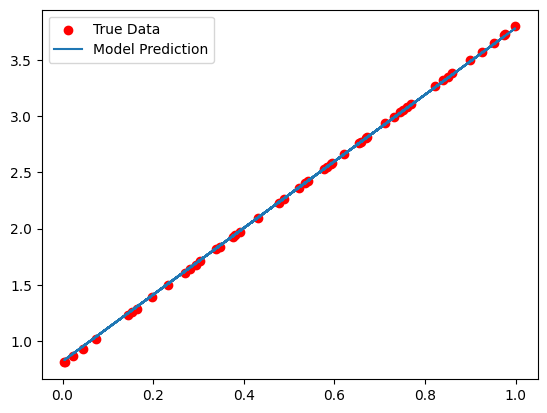

In [104]:
# 可视化结果
predict = x * w + b
plt.scatter(x.data.numpy(), y.data.numpy(), c="r", label="True Data")
plt.plot(x.data.numpy(), predict.data.numpy(), label="Model Prediction")
plt.legend()
plt.show()

In [110]:
w, b

(tensor([2.9618], requires_grad=True), tensor([0.8214], requires_grad=True))

### 2 稍微抽象点

In [120]:
model1 = nn.Sequential(
    nn.Linear(2, 64), 
    nn.Linear(64, 1)
    )
model1

Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): Linear(in_features=64, out_features=1, bias=True)
)

In [121]:
x1 = torch.randn(10, 2)
x1

tensor([[ 0.0255,  0.7027],
        [ 1.7626, -0.0687],
        [-0.7545,  0.9445],
        [-1.7154,  0.1899],
        [ 0.7226,  0.2241],
        [ 0.1222, -1.4924],
        [ 0.5908,  0.5034],
        [-1.1390, -0.2400],
        [-0.3358,  0.2481],
        [-0.9394, -0.9343]])

In [122]:
out1 = model1(x)
out1, out1.size()

(tensor([[ 0.2278],
         [-0.0813],
         [ 0.3886],
         [ 0.6761],
         [ 0.2911],
         [ 0.4353],
         [ 0.2929],
         [ 0.2173],
         [ 0.3635],
         [-0.1518]], grad_fn=<AddmmBackward0>),
 torch.Size([10, 1]))

In [8]:
# Data preparation
x = torch.rand([50, 1])
y = x * 3 + 0.8


In [9]:
# Define the linear regression model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)  # Single linear layer for 1 input and 1 output

    def forward(self, x):
        return self.linear(x)

In [10]:
# Model, loss, and optimizer setup
model = LinearRegressionModel()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3)


In [11]:
# Training loop
num_epochs = 30000  # Reduced for faster convergence
log_interval = 200

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    predictions = model(x)  # Forward pass
    loss = criterion(predictions, y)  # Compute loss
    
    optimizer.zero_grad()  # Clear gradients
    loss.backward()  # Backward pass (compute gradients)
    optimizer.step()  # Update model parameters
    
    if (epoch + 1) % log_interval == 0:
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.6f}')


Epoch 200/30000, Loss: 0.520282
Epoch 400/30000, Loss: 0.277937
Epoch 600/30000, Loss: 0.191096
Epoch 800/30000, Loss: 0.157706
Epoch 1000/30000, Loss: 0.142776
Epoch 1200/30000, Loss: 0.134305
Epoch 1400/30000, Loss: 0.128175
Epoch 1600/30000, Loss: 0.122971
Epoch 1800/30000, Loss: 0.118200
Epoch 2000/30000, Loss: 0.113691
Epoch 2200/30000, Loss: 0.109380
Epoch 2400/30000, Loss: 0.105242
Epoch 2600/30000, Loss: 0.101263
Epoch 2800/30000, Loss: 0.097436
Epoch 3000/30000, Loss: 0.093754
Epoch 3200/30000, Loss: 0.090211
Epoch 3400/30000, Loss: 0.086802
Epoch 3600/30000, Loss: 0.083522
Epoch 3800/30000, Loss: 0.080366
Epoch 4000/30000, Loss: 0.077329
Epoch 4200/30000, Loss: 0.074407
Epoch 4400/30000, Loss: 0.071595
Epoch 4600/30000, Loss: 0.068890
Epoch 4800/30000, Loss: 0.066286
Epoch 5000/30000, Loss: 0.063782
Epoch 5200/30000, Loss: 0.061371
Epoch 5400/30000, Loss: 0.059052
Epoch 5600/30000, Loss: 0.056821
Epoch 5800/30000, Loss: 0.054674
Epoch 6000/30000, Loss: 0.052608
Epoch 6200/300

In [12]:
# Evaluation
model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation
    predictions = model(x)  # Get predictions

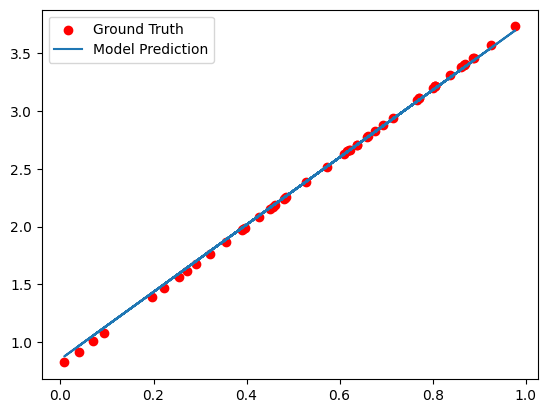

In [13]:
# Visualization
plt.scatter(x.numpy(), y.numpy(), c="r", label="Ground Truth")
plt.plot(x.numpy(), predictions.numpy(), label="Model Prediction")
plt.legend()
plt.show()

### 3 加上gpu

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
# Data preparation
x = torch.rand([50, 1])
y = x * 3 + 0.8

In [4]:
x, y = x.to(device), y.to(device)

In [5]:
# 定义模型
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

# 初始化模型、损失函数和优化器
model = LinearRegressionModel().to(device)  # 将模型移到 GPU
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3)

In [6]:
# 训练循环
num_epochs = 30000
log_interval = 2000

for epoch in range(num_epochs):
    model.train()  # 设置为训练模式
    predictions = model(x)  # 前向传播
    loss = criterion(predictions, y)  # 计算损失

    optimizer.zero_grad()  # 梯度清零
    loss.backward()  # 反向传播
    optimizer.step()  # 参数更新

    if (epoch + 1) % log_interval == 0:
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.6f}')

Epoch 2000/30000, Loss: 0.107741
Epoch 4000/30000, Loss: 0.071449
Epoch 6000/30000, Loss: 0.047519
Epoch 8000/30000, Loss: 0.031604
Epoch 10000/30000, Loss: 0.021019
Epoch 12000/30000, Loss: 0.013979
Epoch 14000/30000, Loss: 0.009297
Epoch 16000/30000, Loss: 0.006184
Epoch 18000/30000, Loss: 0.004113
Epoch 20000/30000, Loss: 0.002735
Epoch 22000/30000, Loss: 0.001819
Epoch 24000/30000, Loss: 0.001210
Epoch 26000/30000, Loss: 0.000805
Epoch 28000/30000, Loss: 0.000535
Epoch 30000/30000, Loss: 0.000356


In [7]:
# Evaluation
model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation
    predictions = model(x)  # Get predictions

In [8]:
# 将数据从 GPU 移回 CPU 以便可视化
x_cpu = x.cpu().numpy()
y_cpu = y.cpu().numpy()
predictions_cpu = predictions.cpu().numpy()

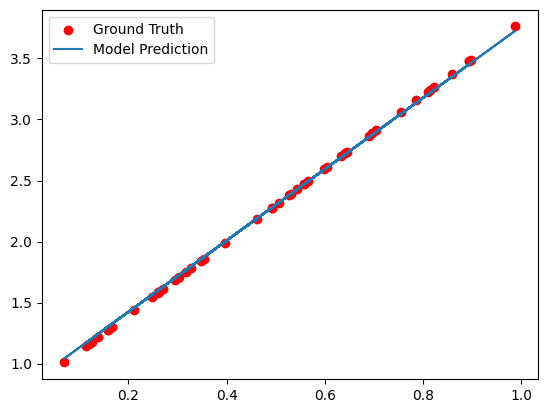

In [9]:
# 绘图
plt.scatter(x_cpu, y_cpu, c="r", label="Ground Truth")  # 实际值
plt.plot(x_cpu, predictions_cpu, label="Model Prediction")  # 模型预测
plt.legend()
plt.show()